In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
adult = fetch_ucirepo(id=2) 
  
# data (as pandas dataframes) 
X = adult.data.features 
y = adult.data.targets 
  
# metadata 
print(adult.metadata) 
  
# variable information 
print(adult.variables) 

{'uci_id': 2, 'name': 'Adult', 'repository_url': 'https://archive.ics.uci.edu/dataset/2/adult', 'data_url': 'https://archive.ics.uci.edu/static/public/2/data.csv', 'abstract': 'Predict whether annual income of an individual exceeds $50K/yr based on census data. Also known as "Census Income" dataset. ', 'area': 'Social Science', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 48842, 'num_features': 14, 'feature_types': ['Categorical', 'Integer'], 'demographics': ['Age', 'Income', 'Education Level', 'Other', 'Race', 'Sex'], 'target_col': ['income'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1996, 'last_updated': 'Tue Sep 24 2024', 'dataset_doi': '10.24432/C5XW20', 'creators': ['Barry Becker', 'Ronny Kohavi'], 'intro_paper': None, 'additional_info': {'summary': "Extraction was done by Barry Becker from the 1994 Census database.  A set of reasonably clean records was extracted using the fol

In [2]:
import pandas as pd

# Combine X and y horizontally
df_complete = pd.concat([X, y], axis=1)

# Export the combined DataFrame to a CSV file
df_complete.to_csv('adult.csv', index=False)

In [3]:
import pandas as pd

# Direct link to the exact same dataset
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df_ins = pd.read_csv(url)


print(df_ins.head())

df_ins.to_csv('insurance.csv', index=False)

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


Solve Question 1

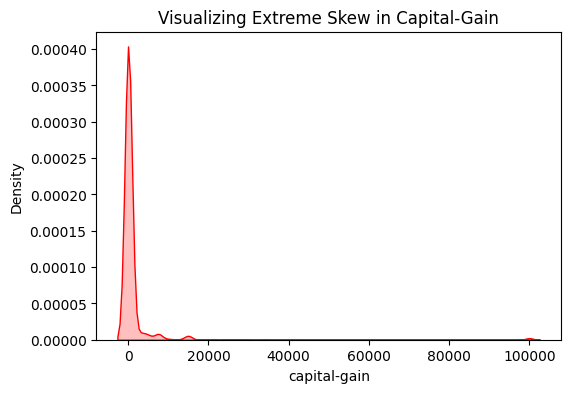

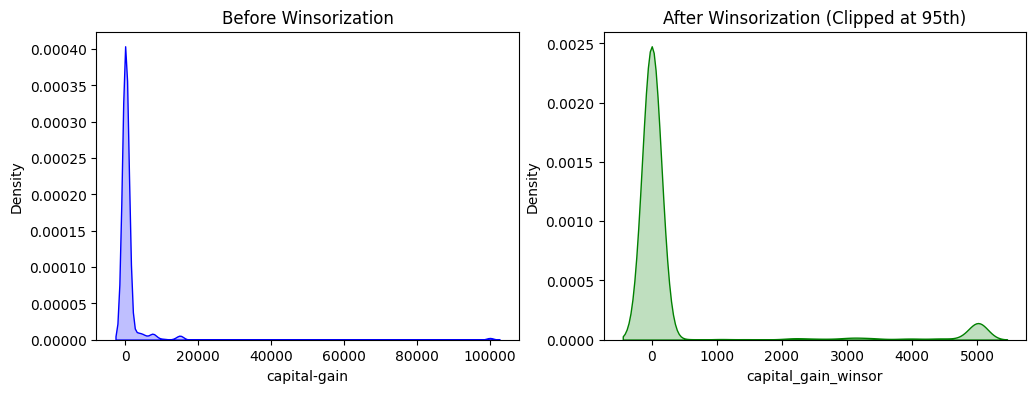

StandardScaler Range: -0.14552350385541205 to 13.187777170087626
RobustScaler Range: 0.0 to 99999.0


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler



columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
           'hours-per-week', 'native-country', 'income']
df_adult=pd.read_csv('adult.csv')
#df_adult = pd.read_csv(url, names=columns, sep=r',\s*', engine='python')
df_adult.replace('?', np.nan, inplace=True)


X = df_adult.drop('income', axis=1)
y = df_adult['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KDE Plot (Before)
plt.figure(figsize=(6, 4))
sns.kdeplot(X_train['capital-gain'], fill=True, color='red')
plt.title("Visualizing Extreme Skew in Capital-Gain")
plt.show()


lower_bound = X_train['capital-gain'].quantile(0.05)
upper_bound = X_train['capital-gain'].quantile(0.95)

X_train['capital_gain_winsor'] = X_train['capital-gain'].clip(lower_bound, upper_bound)
X_test['capital_gain_winsor'] = X_test['capital-gain'].clip(lower_bound, upper_bound)

# Before/After KDE Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.kdeplot(X_train['capital-gain'], fill=True, ax=axes[0], color='blue')
axes[0].set_title("Before Winsorization")
sns.kdeplot(X_train['capital_gain_winsor'], fill=True, ax=axes[1], color='green')
axes[1].set_title("After Winsorization (Clipped at 95th)")
plt.show()

# ৬. RobustScaler vs StandardScaler
scaler_std = StandardScaler()
scaler_rob = RobustScaler()

std_scaled = scaler_std.fit_transform(X_train[['capital-gain']])
rob_scaled = scaler_rob.fit_transform(X_train[['capital-gain']])

print(f"StandardScaler Range: {std_scaled.min()} to {std_scaled.max()}")
print(f"RobustScaler Range: {rob_scaled.min()} to {rob_scaled.max()}")


In [13]:
#solve question 2

Before: object
After: float64


C:\Users\user\AppData\Local\Temp\ipykernel_24464\2700461984.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_churn['TotalCharges'].fillna(0, inplace=True)


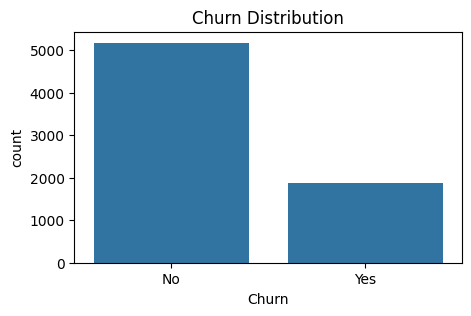

Insight: ডেটাতে ক্লাস ইমব্যালেন্স আছে, Churn 'No' এর সংখ্যা অনেক বেশি।


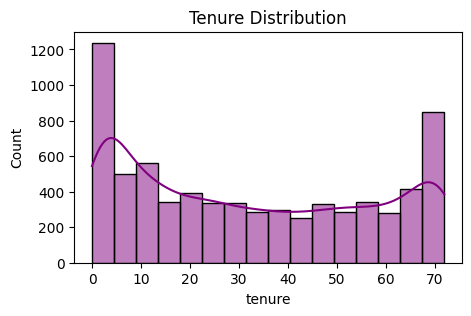

Insight: নতুন গ্রাহকদের (কম মেয়াদের) সংখ্যা অনেক বেশি, যারা দ্রুত চলে যেতে পারে।


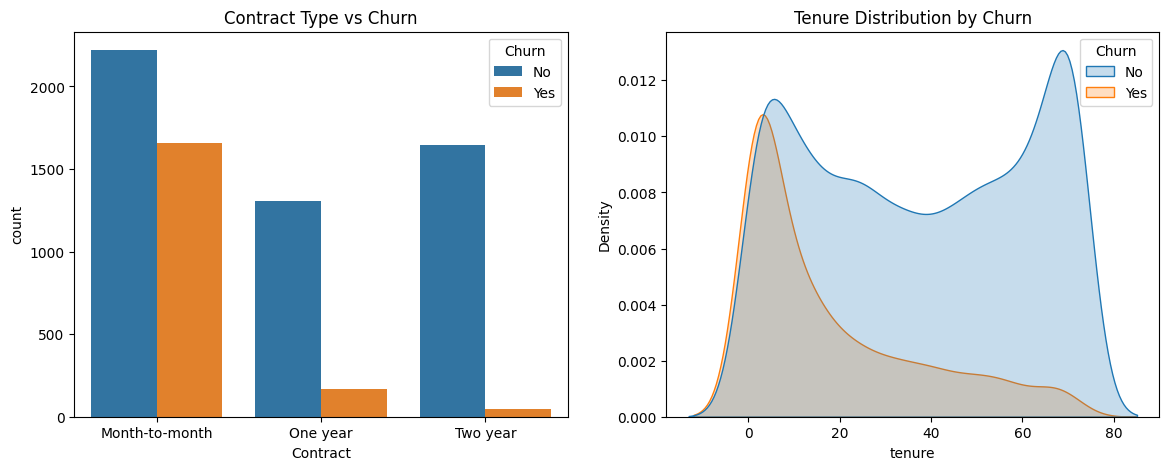


Business Findings to Reduce Churn:
১. Month-to-month চুক্তি সম্পন্ন গ্রাহকদের মধ্যে Churn-এর হার সবচেয়ে বেশি। কোম্পানি তাদের ১ বা ২ বছরের চুক্তিতে আসার জন্য বিশেষ অফার দিতে পারে।
২. প্রথম ১০-১২ মাসের মধ্যে গ্রাহকদের চলে যাওয়ার প্রবণতা সবচেয়ে বেশি। এই সময়ে কাস্টমার কেয়ার থেকে বিশেষ নজর দেওয়া উচিত।



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df_churn = pd.read_csv(url)

print("Before:", df_churn['TotalCharges'].dtypes)

df_churn['TotalCharges'] = df_churn['TotalCharges'].replace(r'^\s*$', np.nan, regex=True)
df_churn['TotalCharges'] = pd.to_numeric(df_churn['TotalCharges'])
df_churn['TotalCharges'].fillna(0, inplace=True)
print("After:", df_churn['TotalCharges'].dtypes)


plt.figure(figsize=(5, 3))
sns.countplot(data=df_churn, x='Churn')
plt.title("Churn Distribution")
plt.show()
print("Insight: ডেটাতে ক্লাস ইমব্যালেন্স আছে, Churn 'No' এর সংখ্যা অনেক বেশি।")

plt.figure(figsize=(5, 3))
sns.histplot(data=df_churn, x='tenure', kde=True, color='purple')
plt.title("Tenure Distribution")
plt.show()
print("Insight: নতুন গ্রাহকদের (কম মেয়াদের) সংখ্যা অনেক বেশি, যারা দ্রুত চলে যেতে পারে।")

# ১২. Multivariate Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Contract vs Churn
sns.countplot(data=df_churn, x='Contract', hue='Churn', ax=axes[0])
axes[0].set_title("Contract Type vs Churn")

# (b) KDE of tenure grouped by Churn
sns.kdeplot(data=df_churn, x='tenure', hue='Churn', fill=True, ax=axes[1])
axes[1].set_title("Tenure Distribution by Churn")
plt.show()

print("""
Business Findings to Reduce Churn:
১. Month-to-month চুক্তি সম্পন্ন গ্রাহকদের মধ্যে Churn-এর হার সবচেয়ে বেশি। কোম্পানি তাদের ১ বা ২ বছরের চুক্তিতে আসার জন্য বিশেষ অফার দিতে পারে।
২. প্রথম ১০-১২ মাসের মধ্যে গ্রাহকদের চলে যাওয়ার প্রবণতা সবচেয়ে বেশি। এই সময়ে কাস্টমার কেয়ার থেকে বিশেষ নজর দেওয়া উচিত।
""")

# question 3

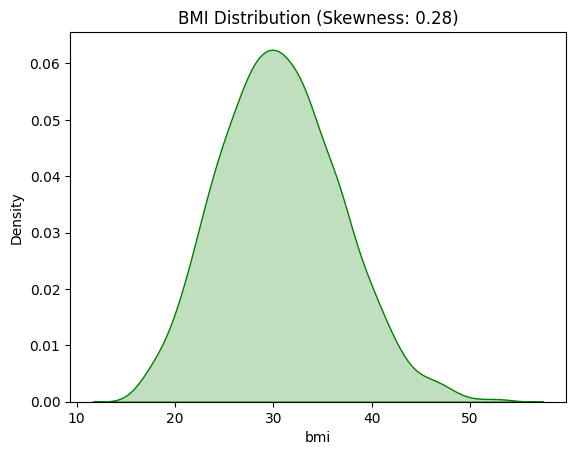

Insight: BMI এর স্কিউনেস ০-এর খুব কাছাকাছি হওয়ায় এটি প্রায় নরমাল ডিস্ট্রিবিউশন।
IQR Detected Outliers: 139
Z-score Detected Outliers: 7
Z-score method is more conservative (strict) here.


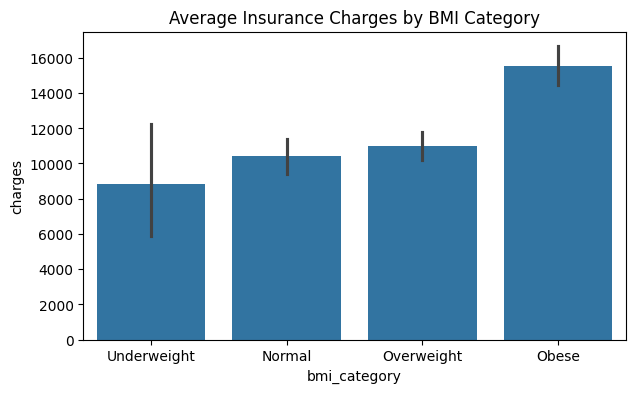

Pattern: ওবেস (Obese) বা স্থূলকায় মানুষের ক্ষেত্রে ইন্সুরেন্স চার্জ আকাশচুম্বী।


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew


url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df_ins = pd.read_csv(url)

sns.kdeplot(df_ins['bmi'], fill=True, color='green')
plt.title(f"BMI Distribution (Skewness: {skew(df_ins['bmi']):.2f})")
plt.show()
print("Insight: BMI এর স্কিউনেস ০-এর খুব কাছাকাছি হওয়ায় এটি প্রায় নরমাল ডিস্ট্রিবিউশন।")


Q1 = df_ins['charges'].quantile(0.25)
Q3 = df_ins['charges'].quantile(0.75)
IQR = Q3 - Q1
iqr_outliers = df_ins[(df_ins['charges'] < (Q1 - 1.5 * IQR)) | (df_ins['charges'] > (Q3 + 1.5 * IQR))]

# (b) Z-score Method
charges_mean = df_ins['charges'].mean()
charges_std = df_ins['charges'].std()
z_scores = (df_ins['charges'] - charges_mean) / charges_std
z_outliers = df_ins[np.abs(z_scores) > 3]

print(f"IQR Detected Outliers: {len(iqr_outliers)}")
print(f"Z-score Detected Outliers: {len(z_outliers)}")
print("Z-score method is more conservative (strict) here.")


def cat_bmi(bmi):
    if bmi < 18.5: return 'Underweight'
    elif bmi < 25: return 'Normal'
    elif bmi < 30: return 'Overweight'
    else: return 'Obese'

df_ins['bmi_category'] = df_ins['bmi'].apply(cat_bmi)

plt.figure(figsize=(7, 4))
sns.barplot(data=df_ins, x='bmi_category', y='charges', order=['Underweight', 'Normal', 'Overweight', 'Obese'])
plt.title("Average Insurance Charges by BMI Category")
plt.show()
print("Pattern: ওবেস (Obese) বা স্থূলকায় মানুষের ক্ষেত্রে ইন্সুরেন্স চার্জ আকাশচুম্বী।")

C:\Users\user\AppData\Local\Temp\ipykernel_24464\4080190176.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=combined, x='Ladder score', y='Country name', palette='coolwarm')


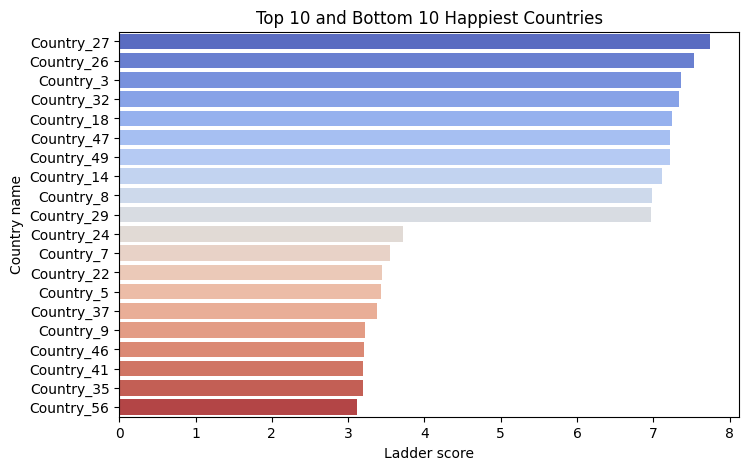

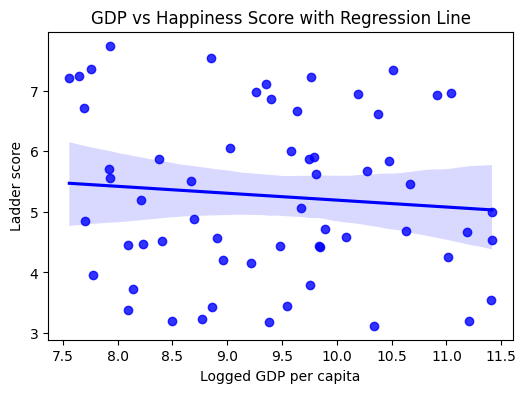

Regional Means:
 Regional indicator
Sub-Saharan Africa    5.781678
South Asia            5.191747
Western Europe        5.173170
Latin America         4.830490
Name: Ladder score, dtype: float64


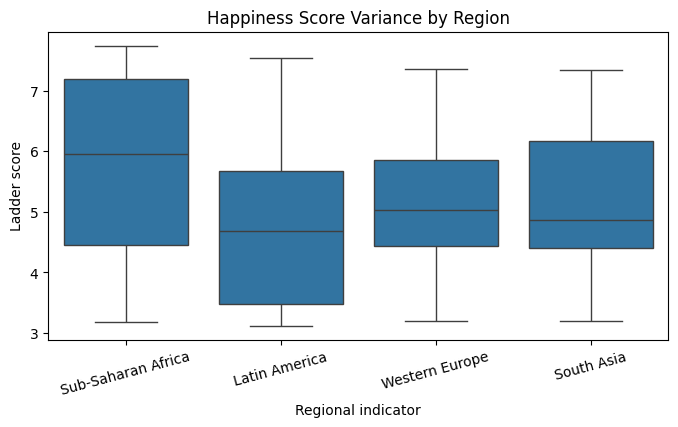

Insight: বক্সপ্লটের উইস্কার (Whiskers) এবং বাক্সের আকার দেখে বুঝা যাবে কোন অঞ্চলে সুখের তারতম্য বা ভ্যারিয়েন্স সবচেয়ে বেশি।


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ২৭. ডেমো হ্যাপিনেস ডেটা লোড ও টপ/বটম ১০ ভিজ্যুয়ালাইজেশন
# বাস্তব ডেটার কলামের সাথে মিল রেখে তৈরি ডেমো সেট
np.random.seed(10)
countries = [f"Country_{i}" for i in range(1, 61)]
demo_happy = {
    'Country name': countries,
    'Regional indicator': np.random.choice(['Western Europe', 'South Asia', 'Sub-Saharan Africa', 'Latin America'], 60),
    'Ladder score': np.random.uniform(3.0, 7.8, 60),
    'Logged GDP per capita': np.random.uniform(7.5, 11.5, 60)
}
df_happy = pd.DataFrame(demo_happy).sort_values(by='Ladder score', ascending=False)

top_10 = df_happy.head(10)
bottom_10 = df_happy.tail(10)
combined = pd.concat([top_10, bottom_10])

plt.figure(figsize=(8, 5))
colors = ['emerald' if x in top_10['Country name'].values else 'crimson' for x in combined['Country name']]
sns.barplot(data=combined, x='Ladder score', y='Country name', palette='coolwarm')
plt.title("Top 10 and Bottom 10 Happiest Countries")
plt.show()

# ২৮. Regression Plot
plt.figure(figsize=(6, 4))
sns.regplot(data=df_happy, x='Logged GDP per capita', y='Ladder score', color='blue')
plt.title("GDP vs Happiness Score with Regression Line")
plt.show()

# ২৯. আঞ্চলিক বিশ্লেষণ (Regional Analysis) ও বক্সপ্লট
regional_mean = df_happy.groupby('Regional indicator')['Ladder score'].mean().sort_values(ascending=False)
print("Regional Means:\n", regional_mean)

plt.figure(figsize=(8, 4))
sns.boxplot(data=df_happy, x='Regional indicator', y='Ladder score')
plt.title("Happiness Score Variance by Region")
plt.xticks(rotation=15)
plt.show()
print("Insight: বক্সপ্লটের উইস্কার (Whiskers) এবং বাক্সের আকার দেখে বুঝা যাবে কোন অঞ্চলে সুখের তারতম্য বা ভ্যারিয়েন্স সবচেয়ে বেশি।")

In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.ensemble import RandomForestRegressor


url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
df = pd.read_csv(url)

X = df.drop('charges', axis=1)
y = df['charges']


Q1 = X['bmi'].quantile(0.25)
Q3 = X['bmi'].quantile(0.75)
IQR = Q3 - Q1
X['bmi'] = X['bmi'].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)

numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']


numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


full_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(random_state=42))
])


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
full_pipeline.fit(X_train, y_train)

print(f"Pipeline Successfully Trained! Test R2 Score: {full_pipeline.score(X_test, y_test):.4f}")

Pipeline Successfully Trained! Test R2 Score: 0.8637
